## 전체 구조


In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

# 1️⃣ State: 카운터를 저장하는 상자
class CounterState(TypedDict):
    count: int

# 2️⃣ Node: 카운터를 증가시키는 함수
def increment(state):
    print(f"현재 카운트: {state['count']}")
    new_count = state["count"] + 1
    print(f"새로운 카운트: {new_count}")
    return {"count": new_count}

# 3️⃣ Edge: 노드들을 연결하는 그래프
graph = StateGraph(CounterState)
graph.add_node("increment", increment)
graph.add_edge(START, "increment")
graph.add_edge("increment", END)

# 실행해보기
app = graph.compile()
result = app.invoke({"count": 0})
print(f"최종 결과: {result}")


현재 카운트: 0
새로운 카운트: 1
최종 결과: {'count': 1}


## 두개의 노드 연결하기

첫 번째 증가
두 번째 증가
최종 결과: {'count': 11}


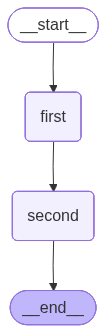

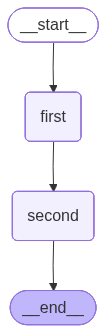

In [7]:
# 첫 번째 증가 함수
def first_increment(state):
    print("첫 번째 증가")
    return {"count": state["count"] + 1}

# 두 번째 증가 함수  
def second_increment(state):
    print("두 번째 증가")
    return {"count": state["count"] + 10}

# 그래프 구성
graph = StateGraph(CounterState)
graph.add_node("first", first_increment)
graph.add_node("second", second_increment)

# 연결: START → first → second → END
graph.add_edge(START, "first")
graph.add_edge("first", "second") 
graph.add_edge("second", END)

# 실행
app = graph.compile()
result = app.invoke({"count": 0})
print(f"최종 결과: {result}")

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
display(Image(app.get_graph(xray=True).draw_mermaid_png()))


## operator.add 함수의 동작

In [8]:
from operator import add

# 리스트의 경우
result = add([1, 2], [3, 4])  # [1, 2, 3, 4]
print(result)

# 문자열의 경우
result = add("Hello", " World")  # "Hello World"
print(result)

# 숫자의 경우
result = add(5, 3)  # 8
print(result)


from rich.pretty import pprint
pprint(result)


[1, 2, 3, 4]
Hello World
8


8

## 상태 업데이트 실습

In [9]:
from typing import Annotated
from typing_extensions import TypedDict
from operator import add
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    message_count: int                           # 기본 리듀서 (덮어쓰기)
    conversation: Annotated[list[str], add]      # add 리듀서 (리스트 연결)

def node_1(state: State) -> State:
    """
    첫 번째 노드: 대화 시작
    - message_count를 1로 설정
    - conversation에 인사말 추가
    """
    print(f"Node 1 - 현재 대화: {state.get('conversation', [])}")
    return {
        "message_count": 1,
        "conversation": ["안녕하세요!"]
    }

def node_2(state: State) -> State:
    """
    두 번째 노드: 대화 이어가기
    - message_count는 업데이트하지 않음 (이전 값 유지)
    - conversation에 새 메시지 추가 (add 리듀서로 누적)
    """
    print(f"Node 2 - 현재 대화: {state['conversation']}")
    # message_count를 반환하지 않으므로 node_1에서 설정한 값이 유지됨
    return {
        "conversation": ["어떻게 도와드릴까요?"]
    }

# 그래프 구성
graph = StateGraph(State)
graph.add_node("node_1", node_1)
graph.add_node("node_2", node_2)
graph.add_edge(START, "node_1")  # 시작 -> node_1
graph.add_edge("node_1", "node_2")  # node_1 -> node_2
graph.add_edge("node_2", END)  # node_2 -> 종료

compiled_graph = graph.compile()

# 실행
initial_state = {"message_count": 0, "conversation": []}
result = compiled_graph.invoke(initial_state)

print("\n=== 최종 결과 ===")
print(f"메시지 수: {result['message_count']}")
print(f"대화 내용: {result['conversation']}")

# 출력:
# Node 1 - 현재 대화: []
# Node 2 - 현재 대화: ['안녕하세요!']
#
# === 최종 결과 ===
# 메시지 수: 1
# 대화 내용: ['안녕하세요!', '어떻게 도와드릴까요?']


Node 1 - 현재 대화: []
Node 2 - 현재 대화: ['안녕하세요!']

=== 최종 결과 ===
메시지 수: 1
대화 내용: ['안녕하세요!', '어떻게 도와드릴까요?']


## 복합 리듀서 활용 예제

In [14]:
from typing import Annotated
from typing_extensions import TypedDict
from operator import add
from langgraph.graph import StateGraph, START, END


def max_reducer(a, b):
    return max(a, b)

def keep_last_n(existing: list, new: list, n: int = 5) -> list:
    """최근 n개 항목만 유지하는 리듀서"""
    combined = (existing or []) + (new or [])
    return combined[-n:]  # 마지막 n개만 반환

# 부분 함수로 리듀서 생성
from functools import partial
keep_last_5 = partial(keep_last_n, n=5)

class AdvancedState(TypedDict):
    total_tokens: Annotated[int, add]           # 토큰 수 누적
    max_score: Annotated[float, max_reducer]            # 최고 점수 유지
    recent_actions: Annotated[list, keep_last_5] # 최근 5개 액션만 유지
    current_status: str                          # 현재 상태 (덮어쓰기)

def process_input(state: AdvancedState) -> AdvancedState:
    """사용자 입력 처리"""
    return {
        "total_tokens": 150,  # 150 토큰 추가
        "max_score": 0.85,    # 점수 0.85
        "recent_actions": ["input_received"],
        "current_status": "processing"
    }

def analyze_content(state: AdvancedState) -> AdvancedState:
    """콘텐츠 분석"""
    return {
        "total_tokens": 200,  # 200 토큰 추가
        "max_score": 0.92,    # 더 높은 점수
        "recent_actions": ["analysis_started", "analysis_completed"],
        "current_status": "analyzed"
    }

def generate_response(state: AdvancedState) -> AdvancedState:
    """응답 생성"""
    return {
        "total_tokens": 300,  # 300 토큰 추가
        "max_score": 0.88,    # 낮은 점수 (무시됨)
        "recent_actions": ["response_generated"],
        "current_status": "completed"
    }

# 그래프 구성 및 실행
graph = StateGraph(AdvancedState)
graph.add_node("process", process_input)
graph.add_node("analyze", analyze_content)
graph.add_node("generate", generate_response)

graph.add_edge(START, "process")
graph.add_edge("process", "analyze")
graph.add_edge("analyze", "generate")
graph.add_edge("generate", END)

compiled_graph = graph.compile()

result = compiled_graph.invoke({
    "total_tokens": 0,
    "max_score": 0.0,
    "recent_actions": [],
    "current_status": "idle"
})

print("=== 최종 상태 ===")
print(f"총 토큰 수: {result['total_tokens']}")  # 650 (150+200+300)
print(f"최고 점수: {result['max_score']}")      # 0.92 (최대값)
print(f"최근 액션: {result['recent_actions']}")  # 최근 5개
print(f"현재 상태: {result['current_status']}")  # "completed"


=== 최종 상태 ===
총 토큰 수: 650
최고 점수: 0.92
최근 액션: ['input_received', 'analysis_started', 'analysis_completed', 'response_generated']
현재 상태: completed


## max 에러문제
- 위에서 max_reducer 사용하여 우회처리

In [13]:
import sys, inspect
print(sys.version)
print(sys.executable)
print(inspect.signature(max))

3.11.15 (main, Mar 10 2026, 18:12:25) [MSC v.1944 64 bit (AMD64)]
d:\MyProject\_LLM\LangGraph_wiki\.venv\Scripts\python.exe


ValueError: no signature found for builtin <built-in function max>

## 실전 예제: 간단한 챗봇

In [15]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import HumanMessage, AIMessage

class ChatState(MessagesState):
    user_name: str

def greet_user(state: ChatState) -> dict:
    """사용자 인사 처리"""
    user_msg = state["messages"][-1]
    response = AIMessage(
        content=f"안녕하세요, {state['user_name']}님! 무엇을 도와드릴까요?"
    )
    return {"messages": [response]}

def process_question(state: ChatState) -> dict:
    """질문 처리"""
    user_msg = state["messages"][-1]
    response = AIMessage(
        content=f"'{user_msg.content}'에 대한 답변입니다."
    )
    return {"messages": [response]}

# 그래프 구성
graph = StateGraph(ChatState)
graph.add_node("greet", greet_user)
graph.add_node("answer", process_question)

graph.add_edge(START, "greet")
graph.add_edge("greet", "answer")
graph.add_edge("answer", END)

app = graph.compile()

# 실행
result = app.invoke({
    "messages": [HumanMessage(content="안녕하세요")],
    "user_name": "홍길동"
})

print(f"메시지 수: {len(result['messages'])}")
for msg in result["messages"]:
    role = "User" if isinstance(msg, HumanMessage) else "AI"
    print(f"{role}: {msg.content}")


메시지 수: 3
User: 안녕하세요
AI: 안녕하세요, 홍길동님! 무엇을 도와드릴까요?
AI: '안녕하세요, 홍길동님! 무엇을 도와드릴까요?'에 대한 답변입니다.


## Private State

In [16]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# 공개 상태 - 그래프 입출력에 사용
class PublicState(TypedDict):
    user_query: str
    final_answer: str

# 비공개 상태 - 내부 노드 간 통신용
class PrivateState(TypedDict):
    intermediate_result: str
    processing_metadata: dict

def node_1(state: PublicState) -> PrivateState:
    """첫 번째 노드: 공개 상태를 읽고 비공개 상태로 출력"""
    query = state["user_query"]

    # 중간 처리 결과를 비공개 상태로 저장
    return {
        "intermediate_result": f"처리됨: {query}",
        "processing_metadata": {"step": 1, "status": "preprocessed"}
    }

def node_2(state: PrivateState) -> PublicState:
    """두 번째 노드: 비공개 상태를 읽고 공개 상태로 출력"""
    intermediate = state["intermediate_result"]
    metadata = state["processing_metadata"]

    # 비공개 상태를 처리하여 최종 공개 결과 생성
    return {
        "final_answer": f"완료! {intermediate} (단계: {metadata['step']})"
    }

def node_3(state: PublicState) -> dict:
    """세 번째 노드: 공개 상태만 접근 (비공개 상태 접근 불가)"""
    return {"final_answer": state["final_answer"] + " [검증됨]"}

# 그래프 구성
builder = StateGraph(PublicState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)

graph = builder.compile()

# 실행
result = graph.invoke({"user_query": "Python이란?"})
print(result)
# {'user_query': 'Python이란?', 'final_answer': '완료! 처리됨: Python이란? (단계: 1) [검증됨]'}


{'user_query': 'Python이란?', 'final_answer': '완료! 처리됨: Python이란? (단계: 1) [검증됨]'}
